In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat0 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_basic.fits'))
cat = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_photom.fits'))
cat1 = Table(fitsio.read('/global/cscratch1/sd/rongpu/target/catalogs/dr9.0/0.49.0/dr9_sv1_lrg_south_0.49.0_more_1.fits'))
cat = hstack([cat0, cat, cat1], join_type='exact')
print(len(cat))

31485458


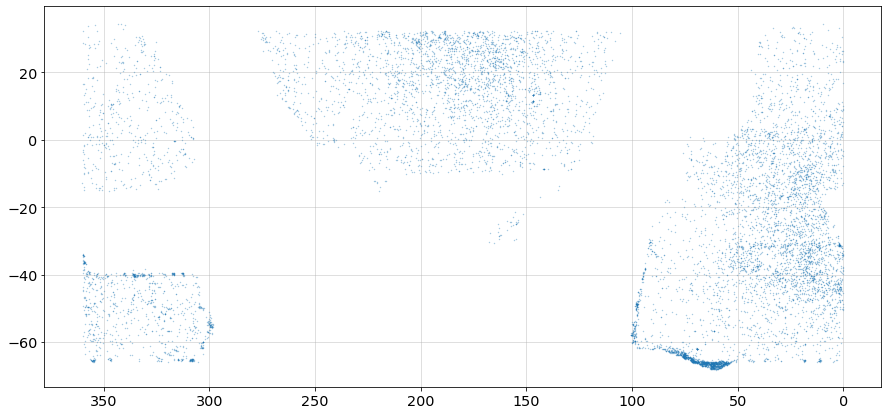

In [4]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [5]:
mask = cat['DEC']>-30
cat = cat[mask]
print(len(cat))

24978592


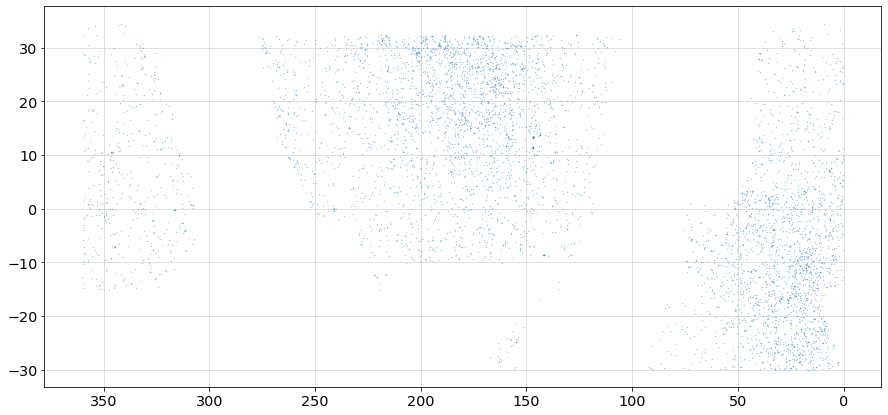

In [6]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
# mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.figure(figsize=(15, 7))
plt.plot(cat['RA'][mask], cat['DEC'][mask], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

In [8]:
lrg_opt = cat['SV1_DESI_TARGET'] & 2**3 > 0
print(np.sum(lrg_opt)/len(cat))

lrg_ir = cat['SV1_DESI_TARGET'] & 2**4 > 0
print(np.sum(lrg_ir)/len(cat))

0.2791608510199454
0.2878260311870261


In [30]:
mask = cat['MORPHTYPE']=='PSF'
print(np.sum(mask)/len(cat))

0.06464211433534764


In [31]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))

0.01354728080750108


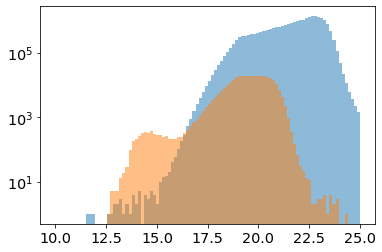

In [32]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
plt.hist(cat['rmag'][~mask], 100, range=(10, 25), log=True, alpha=0.5)
plt.hist(cat['rmag'][mask], 100, range=(10, 25), log=True, alpha=0.5)
plt.show()

In [33]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
cat['GAIA_PHOT_G_MEAN_MAG'][mask].min()

13.0008

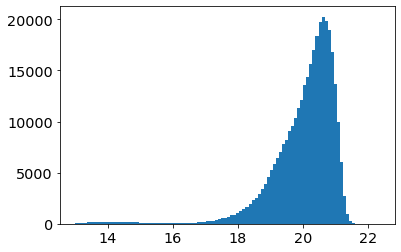

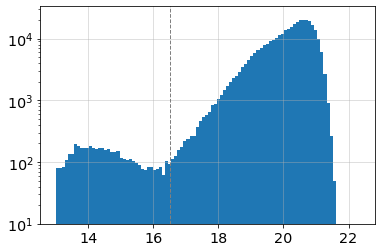

In [34]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100)
plt.show()

plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True)
plt.grid(alpha=0.5)
plt.ylim(ymin=10)
plt.axvline(16.5, ls='--', lw=1, color='gray')
plt.show()

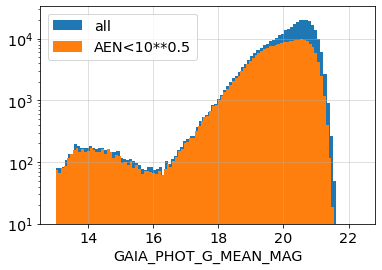

In [35]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask1 = mask & (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True, label='all')
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask1], 100, log=True, label='AEN<10**0.5')
plt.grid(alpha=0.5)
plt.ylim(ymin=10)
# plt.axvline(16.5, ls='--', lw=1, color='gray')
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.legend()
plt.show()

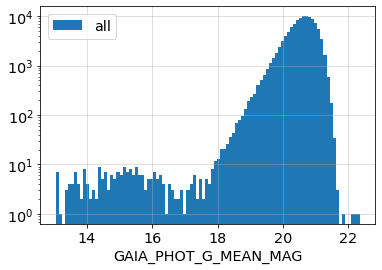

In [49]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>10**0.5)
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 100, log=True, label='all')
plt.grid(alpha=0.5)
# plt.ylim(ymin=10)
# plt.axvline(16.5, ls='--', lw=1, color='gray')
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.legend()
plt.show()

In [36]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG']<16.)
print(np.sum(mask), np.sum(mask)/len(cat))

4181 0.00016738333369631082


0.01354728080750108


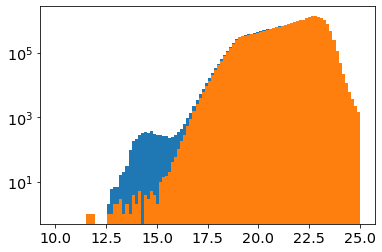

0.00912081033230376


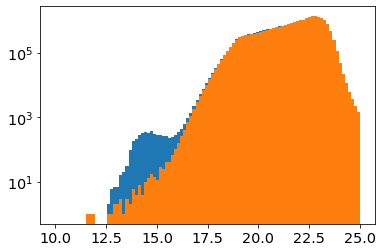

In [37]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))
plt.hist(cat['rmag'], 100, log=True, range=(10, 25))
plt.hist(cat['rmag'][~mask], 100, log=True, range=(10, 25))
plt.show()

mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
print(np.sum(mask)/len(cat))
plt.hist(cat['rmag'], 100, log=True, range=(10, 25))
plt.hist(cat['rmag'][~mask], 100, log=True, range=(10, 25))
plt.show()

0.01354728080750108


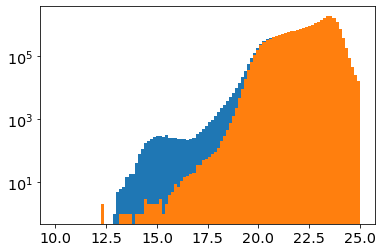

0.00912081033230376


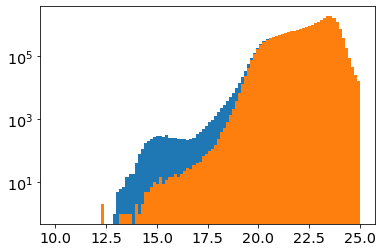

In [38]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
print(np.sum(mask)/len(cat))
plt.hist(cat['rfibermag'], 100, log=True, range=(10, 25))
plt.hist(cat['rfibermag'][~mask], 100, log=True, range=(10, 25))
plt.show()

mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
print(np.sum(mask)/len(cat))
plt.hist(cat['rfibermag'], 100, log=True, range=(10, 25))
plt.hist(cat['rfibermag'][~mask], 100, log=True, range=(10, 25))
plt.show()

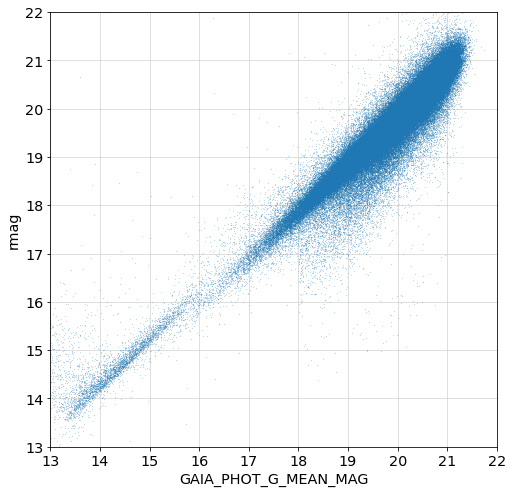

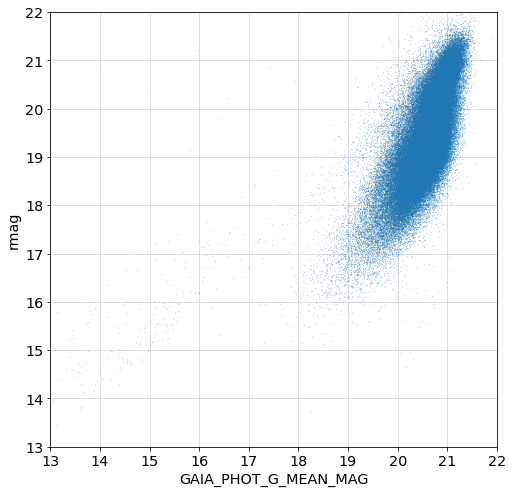

In [39]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask1 = mask & (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask2 = mask & (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>=10**0.5)

plt.figure(figsize=(8, 8))
plt.plot(cat['GAIA_PHOT_G_MEAN_MAG'][mask1], cat['rmag'][mask1], '.', ms=0.2)
# plt.plot(cat['GAIA_PHOT_G_MEAN_MAG'][mask2], cat['rmag'][mask2], '.', ms=1)
plt.axis([13, 22, 13, 22])
plt.grid(alpha=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('rmag')
plt.show()

plt.figure(figsize=(8, 8))
# plt.plot(cat['GAIA_PHOT_G_MEAN_MAG'][mask1], cat['rmag'][mask1], '.', ms=0.2)
plt.plot(cat['GAIA_PHOT_G_MEAN_MAG'][mask2], cat['rmag'][mask2], '.', ms=0.2)
plt.axis([13, 22, 13, 22])
plt.grid(alpha=0.5)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('rmag')
plt.show()

In [57]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>=10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_1.txt', format='ascii.no_header', overwrite=True)

201
82


In [58]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_2.txt', format='ascii.no_header', overwrite=True)

5197
5197


In [44]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 17.5) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_3.txt', format='ascii.no_header', overwrite=True)

3839
3839


In [50]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>=10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 17) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
print(cat['GAIA_PHOT_G_MEAN_MAG'][mask].min())

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_4.txt', format='ascii.no_header', overwrite=True)

17.084791
54
23


In [47]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']>=10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] > 16) & (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_5.txt', format='ascii.no_header', overwrite=True)

39
15


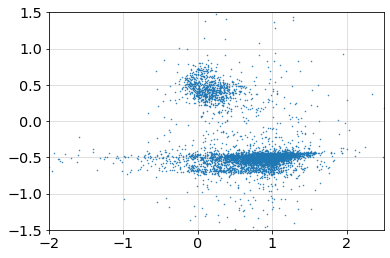

In [107]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)

plt.plot((cat['rmag']-cat['zmag'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.grid(alpha=0.5)
plt.axis([-2, 2.5, -1.5, 1.5])
plt.show()

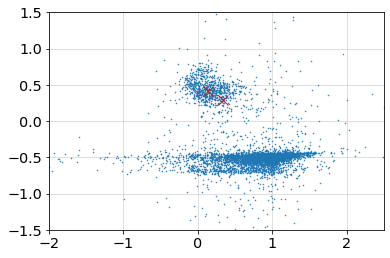

In [23]:
plt.plot((cat['rmag']-cat['zmag'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['rmag']-cat['zmag'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.grid(alpha=0.5)
plt.axis([-2, 2.5, -1.5, 1.5])
plt.show()

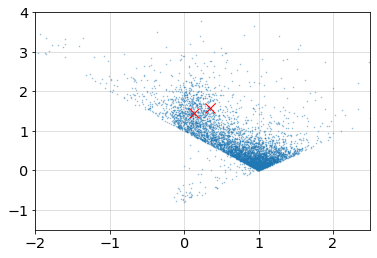

In [111]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask1 = mask & (cat['Z_SPEC']!=-99)

plt.plot((cat['rmag']-cat['zmag'])[mask], (cat['zmag']-cat['w1mag'])[mask], '.', ms=1, alpha=0.5)
plt.plot((cat['rmag']-cat['zmag'])[mask1], (cat['zmag']-cat['w1mag'])[mask1], 'rx', ms=10)
plt.grid(alpha=0.5)
plt.axis([-2, 2.5, -1.5, 4])
plt.show()

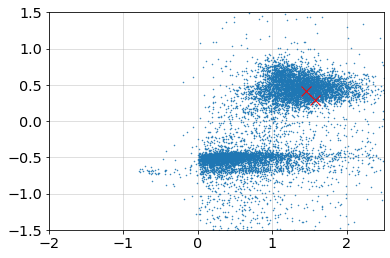

In [31]:
plt.plot((cat['zmag']-cat['w1mag'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['zmag']-cat['w1mag'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.grid(alpha=0.5)
plt.axis([-2, 2.5, -1.5, 1.5])
plt.show()

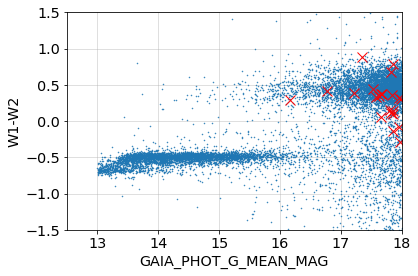

In [128]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask1 = mask & (cat['Z_SPEC']!=-99)

plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [116]:
mask1 = mask & (cat['Z_SPEC']!=-99)
cat[mask1][['Z_SPEC', 'SURVEY']]

Z_SPEC,SURVEY
float32,str10
0.058011968,BOSS
0.2836,GAMA
0.09890207,BOSS
0.0597729,BOSS
0.06685,GAMA
0.11370899,BOSS
0.16343772,SDSS
0.1582452,SDSS
0.081827864,SDSS


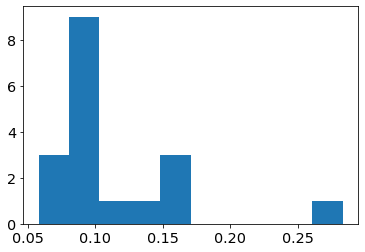

In [118]:
plt.hist(cat['Z_SPEC'][mask1], 10);

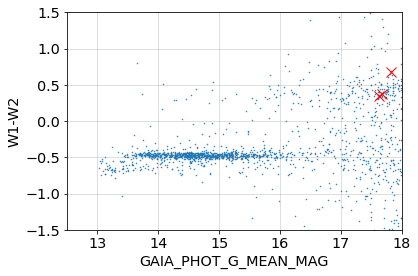

In [129]:
mask = lrg_opt.copy()
mask &= cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask1 = mask & (cat['Z_SPEC']!=-99)

plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

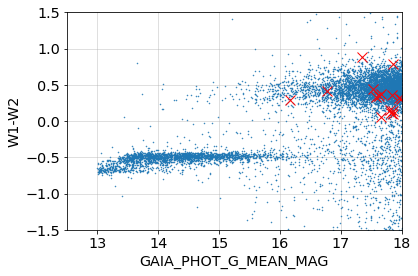

In [123]:
mask = lrg_ir.copy()
mask &= cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask1 = mask & (cat['Z_SPEC']!=-99)

plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [139]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag'])>0
mask &= lrg_opt
print(np.sum(mask))

288


In [141]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)
mask &= (cat['w1mag']-cat['w2mag'])>0
print(np.sum(mask))
mask &= lrg_ir
print(np.sum(mask))

5272
4744


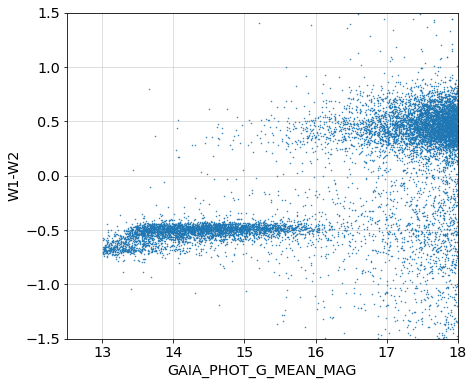

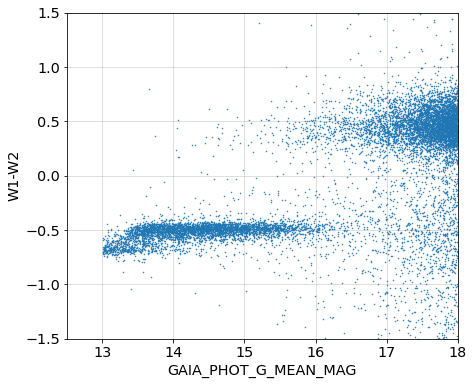

In [92]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_ASTROMETRIC_EXCESS_NOISE']<10**0.5)
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

# Remove the GAIA_ASTROMETRIC_EXCESS_NOISE cut
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [102]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 16)
mask &= (cat['w1mag']-cat['w2mag']>0)

idx = np.where(mask)[0]
print(len(idx))
print(np.sum(cat['MORPHTYPE'][mask]=='PSF'))
if len(idx)>1000:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = cat['RA'][idx]
t['DEC'] = cat['DEC'][idx]
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_agn.txt', format='ascii.no_header', overwrite=True)

183
183


In [105]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 16)
mask &= (cat['w1mag']-cat['w2mag']>0)

idx = np.where(mask)[0]

tmp = cat[idx].copy()
tmp.sort('GAIA_PHOT_G_MEAN_MAG')

t = Table()
t['RA'] = tmp['RA']
t['DEC'] = tmp['DEC']
t.write('/global/u2/r/rongpu/temp/lrg_vi/visual_inspection_agn.txt', format='ascii.no_header', overwrite=True)

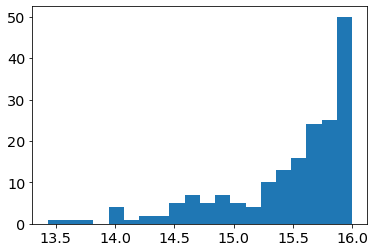

In [103]:
plt.hist(cat['GAIA_PHOT_G_MEAN_MAG'][mask], 20);

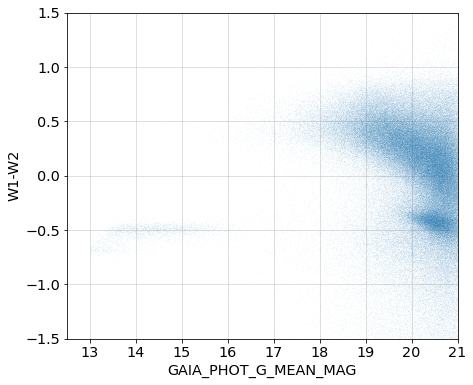

In [101]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 21)

plt.figure(figsize=(7, 6))
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=0.1, alpha=0.2)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 21, -1.5, 1.5])
plt.show()

In [ ]:
mask = 

In [47]:
tt = Table.read("/global/cfs/cdirs/desi/spectro/redux/cascades/zcatalog-cascades-deep.fits")
len(tt)

503500

In [48]:
len(np.unique(tt['TARGETID']))

482560

In [49]:
mask = np.in1d(tt['TARGETID'], cat['TARGETID'])
tt = tt[mask]
print(len(tt))

34367


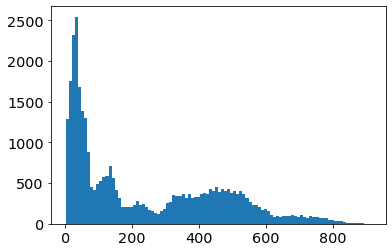

In [50]:
plt.hist(tt['TSNR2_LRG'], 100);

15420


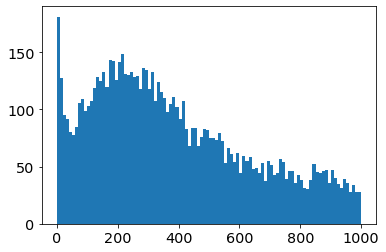

In [65]:
mask = tt['TSNR2_LRG']>200
print(np.sum(mask))
plt.hist(tt['DELTACHI2'][mask], 100, range=(0, 1000));

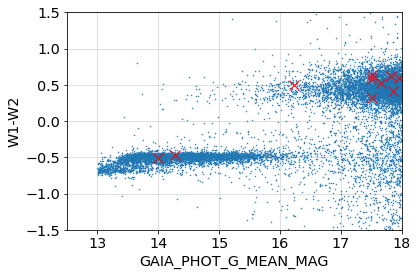

In [84]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 18)

mask_tmp = (tt['TSNR2_LRG']>200) & (tt['DELTACHI2']>100)
mask1 = mask & np.in1d(cat['TARGETID'], tt['TARGETID'][mask_tmp])

plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

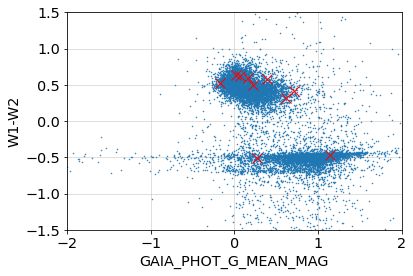

In [88]:
plt.plot((cat['rmag']-cat['zmag'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['rmag']-cat['zmag'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
plt.axis([-2, 2, -1.5, 1.5])
plt.show()

In [79]:
t1 = cat[mask1]
t1 = join(t1, tt['TARGETID', 'Z'], keys='TARGETID')

In [143]:
t1[['Z_PHOT_MEDIAN', 'Z']]

Z_PHOT_MEDIAN,Z
float32,float64
0.018712496,0.8527200067779799
0.20193155,6.99053332266513e-05
0.080235675,0.33904023031571345
0.11572305,0.8135986223124763
0.025435219,0.7816051433182559
0.009219501,-0.0019957014509158224
0.072640024,0.3265276803643466
0.014433497,0.8369044111471924
0.07235957,-2.1429451808162305e-05


In [142]:
t1

RA,DEC,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,PHOTSYS,TARGETID,SV1_DESI_TARGET,SV1_BGS_TARGET,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_W1,FLUX_IVAR_W2,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,SHAPE_R,SERSIC,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,GAIA_ASTROMETRIC_EXCESS_NOISE,FITBITS,Z_PHOT_MEAN,Z_PHOT_MEDIAN,Z_PHOT_STD,Z_PHOT_L68,Z_PHOT_U68,Z_PHOT_L95,Z_PHOT_U95,Z_SPEC,SURVEY,TRAINING,stellar_mass,gmag,rmag,zmag,w1mag,w2mag,rfibermag,zfibermag,Z
float64,float64,int16,int16,int16,int16,str1,int64,int64,int64,str4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,str10,bool,float32,float32,float32,float32,float32,float32,float32,float32,float64
88.65418144687244,-23.505732073252247,7,7,6,0,S,39627233760908751,2306124484274294869,0,PSF,0.04432081,93.27572,99.03244,104.74205,227.92221,234.31151,91.48603,0.87704355,0.91541535,0.9517678,565.68384,1018.99915,0.6237219,0.15371071,0.99251705,0.99539787,72.63062,77.11318,81.55907,0.0,0.0,17.512543,17.632948,17.1693,0.14283842,4224,0.047740243,0.018712496,0.11865241,0.009973122,0.06037942,0.005820279,0.23481,-99.0,,False,9.380584,17.433132,17.414602,17.396025,15.610411,14.974557,17.686224,17.667646,0.8527200067779799
36.48796065629098,-3.3447009726462844,10,7,8,2200,S,39627706828069508,100663393,0,PSF,0.02333028,371.62753,1399.0762,4085.8943,94.44277,6.584537,0.07778488,0.9332685,0.95454407,0.97431374,5059.384,3300.9824,0.089255564,0.05492591,0.996054,0.9975748,191.87674,722.36346,2109.6072,0.0,0.0,14.270352,15.697426,13.104944,0.27523133,4290,0.1988791,0.20193155,0.09151547,0.10117134,0.27080745,0.06026372,0.5359211,-99.0,,False,13.235009,15.999746,14.584887,13.443529,13.235463,13.700756,15.302601,14.1612425,6.99053332266513e-05
150.11431699423724,2.9975661730643712,6,7,6,0,S,39627859723029487,6926817701998375037,0,PSF,0.02066325,50.96368,82.98858,162.4826,245.8357,168.54297,64.471535,0.9406657,0.959634,0.97721636,679.9488,992.6733,0.5177666,0.1458917,0.9965043,0.9978517,39.70161,64.64957,126.57682,0.0,0.0,17.861168,18.113976,17.035194,0.5753192,4224,0.13124594,0.080235675,0.10284073,0.045039985,0.24741699,0.019812351,0.36186248,-99.0,,False,11.103638,18.165436,17.657719,16.94796,15.415008,15.00565,17.92885,17.219091,0.33904023031571345
114.93358016545336,14.944070782250805,2,2,2,0,S,39628145271245098,6926817701956431957,0,PSF,0.042712558,41.58439,43.381634,52.417606,169.08412,84.84708,34.342403,0.8812289,0.9183557,0.9534766,193.0021,333.7271,1.1811051,0.28392956,0.9927876,0.99556446,32.398403,33.798637,40.838566,0.0,0.0,17.950129,18.032526,17.5792,0.19459654,4224,0.1390758,0.11572305,0.09617986,0.04685818,0.24342917,0.015071636,0.36186248,-99.0,,False,9.522085,18.315395,18.314262,18.149582,16.778236,16.186695,18.58528,18.420599,0.8135986223124763
115.99753897697943,18.968828647943162,7,5,4,0,S,39628237843729957,2315131683529044053,0,PSF,0.040691596,63.52737,73.62537,81.60846,351.00943,169.35455,79.899376,0.88651663,0.922064,0.9556283,314.28235,559.3703,0.8569708,0.20731038,0.9931277,0.9957739,49.43495,57.292885,63.505074,0.0,0.0,17.830494,17.98824,17.424234,0.0,4224,0.045353927,0.025435219,0.05335218,0.011803811,0.07091362,0.005794731,0.23481,-99.0,,False,9.901042,17.861814,17.744335,17.671385,16.249212,15.626154,18.016651,17.9437,0.7816051433182559
114.45093219705034,19.867224028565005,5,3,3,2048,S,39628254948103273,2305843009297580113,0,PSF,0.035010077,303.86505,317.60852,400.17752,65.97199,33.310074,23.435658,0.90155256,0.9325696,0.9617033,1792.4038,2843.865,0.22268331,0.060994357,0.9940844,0.99636286,236.43631,247.13005,311.3767,0.0,0.0,16.2331,16.311317,15.865164,0.051470183,4226,0.032083325,0.009219501,0.03

In [80]:
mask = t1['GAIA_PHOT_G_MEAN_MAG']<15
t1['Z'][mask]

6.99053332266513e-05
-2.1429451808162305e-05


In [81]:
mask = t1['GAIA_PHOT_G_MEAN_MAG']>15
t1['Z'][mask]

0.8527200067779799
0.33904023031571345
0.8135986223124763
0.7816051433182559
-0.0019957014509158224
0.3265276803643466
0.8369044111471924
0.3766154267915


In [83]:
mask = t1['GAIA_PHOT_G_MEAN_MAG']>15
t1['GAIA_PHOT_G_MEAN_MAG'][mask]

17.512543
17.861168
17.950129
17.830494
16.2331
17.510366
17.656677
17.504143


In [82]:
(t1['w1mag']-t1['w2mag'])[mask]

0.63585377
0.40935802
0.5915413
0.6230583
0.49869728
0.32507896
0.52523327
0.5788851


In [72]:
t1

RA,DEC,NOBS_G,NOBS_R,NOBS_Z,MASKBITS,PHOTSYS,TARGETID,SV1_DESI_TARGET,SV1_BGS_TARGET,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_W1,FLUX_IVAR_W2,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,SHAPE_R,SERSIC,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,GAIA_ASTROMETRIC_EXCESS_NOISE,FITBITS,Z_PHOT_MEAN,Z_PHOT_MEDIAN,Z_PHOT_STD,Z_PHOT_L68,Z_PHOT_U68,Z_PHOT_L95,Z_PHOT_U95,Z_SPEC,SURVEY,TRAINING,stellar_mass,gmag,rmag,zmag,w1mag,w2mag,rfibermag,zfibermag,Z
float64,float64,int16,int16,int16,int16,str1,int64,int64,int64,str4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,str10,bool,float32,float32,float32,float32,float32,float32,float32,float32,float64
88.65418144687244,-23.505732073252247,7,7,6,0,S,39627233760908751,2306124484274294869,0,PSF,0.04432081,93.27572,99.03244,104.74205,227.92221,234.31151,91.48603,0.87704355,0.91541535,0.9517678,565.68384,1018.99915,0.6237219,0.15371071,0.99251705,0.99539787,72.63062,77.11318,81.55907,0.0,0.0,17.512543,17.632948,17.1693,0.14283842,4224,0.047740243,0.018712496,0.11865241,0.009973122,0.06037942,0.005820279,0.23481,-99.0,,False,9.380584,17.433132,17.414602,17.396025,15.610411,14.974557,17.686224,17.667646,0.8527200067779799
36.48796065629098,-3.3447009726462844,10,7,8,2200,S,39627706828069508,100663393,0,PSF,0.02333028,371.62753,1399.0762,4085.8943,94.44277,6.584537,0.07778488,0.9332685,0.95454407,0.97431374,5059.384,3300.9824,0.089255564,0.05492591,0.996054,0.9975748,191.87674,722.36346,2109.6072,0.0,0.0,14.270352,15.697426,13.104944,0.27523133,4290,0.1988791,0.20193155,0.09151547,0.10117134,0.27080745,0.06026372,0.5359211,-99.0,,False,13.235009,15.999746,14.584887,13.443529,13.235463,13.700756,15.302601,14.1612425,6.99053332266513e-05
150.11431699423724,2.9975661730643712,6,7,6,0,S,39627859723029487,6926817701998375037,0,PSF,0.02066325,50.96368,82.98858,162.4826,245.8357,168.54297,64.471535,0.9406657,0.959634,0.97721636,679.9488,992.6733,0.5177666,0.1458917,0.9965043,0.9978517,39.70161,64.64957,126.57682,0.0,0.0,17.861168,18.113976,17.035194,0.5753192,4224,0.13124594,0.080235675,0.10284073,0.045039985,0.24741699,0.019812351,0.36186248,-99.0,,False,11.103638,18.165436,17.657719,16.94796,15.415008,15.00565,17.92885,17.219091,0.33904023031571345
114.93358016545336,14.944070782250805,2,2,2,0,S,39628145271245098,6926817701956431957,0,PSF,0.042712558,41.58439,43.381634,52.417606,169.08412,84.84708,34.342403,0.8812289,0.9183557,0.9534766,193.0021,333.7271,1.1811051,0.28392956,0.9927876,0.99556446,32.398403,33.798637,40.838566,0.0,0.0,17.950129,18.032526,17.5792,0.19459654,4224,0.1390758,0.11572305,0.09617986,0.04685818,0.24342917,0.015071636,0.36186248,-99.0,,False,9.522085,18.315395,18.314262,18.149582,16.778236,16.186695,18.58528,18.420599,0.8135986223124763
115.99753897697943,18.968828647943162,7,5,4,0,S,39628237843729957,2315131683529044053,0,PSF,0.040691596,63.52737,73.62537,81.60846,351.00943,169.35455,79.899376,0.88651663,0.922064,0.9556283,314.28235,559.3703,0.8569708,0.20731038,0.9931277,0.9957739,49.43495,57.292885,63.505074,0.0,0.0,17.830494,17.98824,17.424234,0.0,4224,0.045353927,0.025435219,0.05335218,0.011803811,0.07091362,0.005794731,0.23481,-99.0,,False,9.901042,17.861814,17.744335,17.671385,16.249212,15.626154,18.016651,17.9437,0.7816051433182559
114.45093219705034,19.867224028565005,5,3,3,2048,S,39628254948103273,2305843009297580113,0,PSF,0.035010077,303.86505,317.60852,400.17752,65.97199,33.310074,23.435658,0.90155256,0.9325696,0.9617033,1792.4038,2843.865,0.22268331,0.060994357,0.9940844,0.99636286,236.43631,247.13005,311.3767,0.0,0.0,16.2331,16.311317,15.865164,0.051470183,4226,0.032083325,0.009219501,0.03

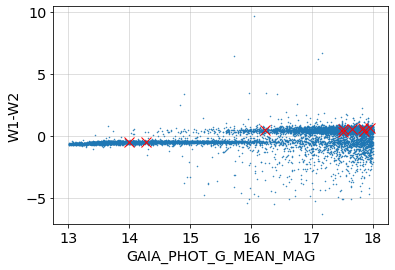

In [54]:
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask], (cat['w1mag']-cat['w2mag'])[mask], '.', ms=1)
plt.plot((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
# plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [ ]:
plt.scatter((cat['GAIA_PHOT_G_MEAN_MAG'])[mask1], (cat['w1mag']-cat['w2mag'])[mask1], 'rx', ms=10)
plt.xlabel('GAIA_PHOT_G_MEAN_MAG')
plt.ylabel('W1-W2')
plt.grid(alpha=0.5)
# plt.axis([12.5, 18, -1.5, 1.5])
plt.show()

In [124]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [127]:
cat['z_phot'] = cat['Z_PHOT_MEDIAN']

930


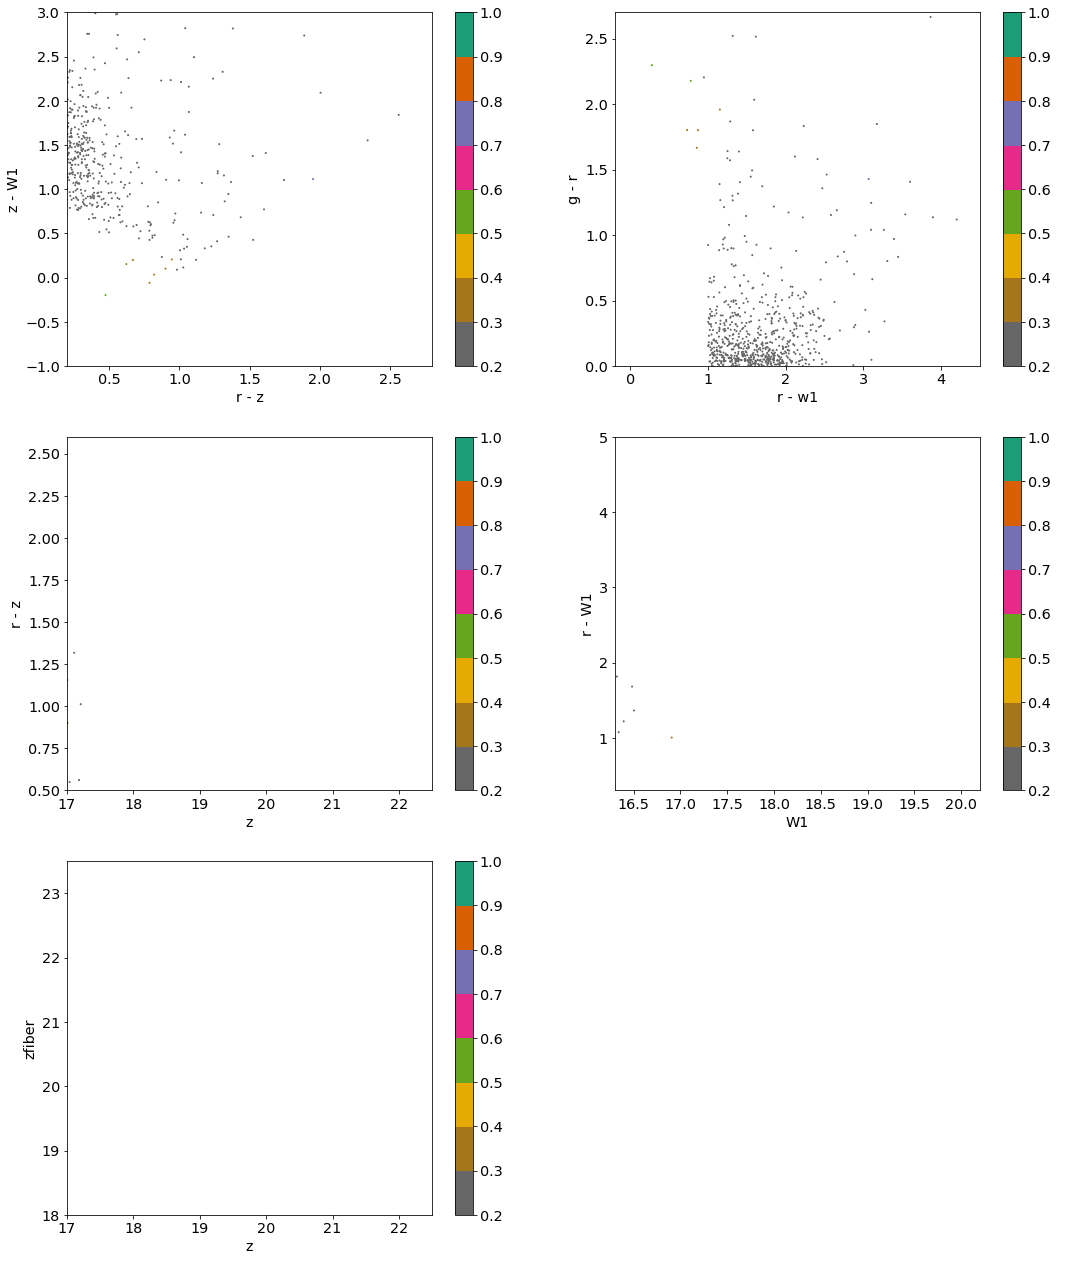

In [136]:
mask = cat['GAIA_PHOT_G_MEAN_MAG']!=0
mask &= (cat['GAIA_PHOT_G_MEAN_MAG'] < 17)
mask &= (cat['w1mag']-cat['w2mag']>0)
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(cat[mask], ms=1)